# Distance-Matrix Distance-CRP

> Reveal semantic contiguity in recall transitions using a precomputed distance matrix.

This companion template mirrors the standard Distance-CRP workflow, but passes `distance_matrix=` directly instead of loading item feature vectors. This is useful when semantic structure is available as pairwise ratings rather than embeddings.


## Workflow


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import warnings
from jaxcmr.analyses.distcrp import plot_dist_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")


In [2]:
data_path = "data/Dupertuys2026.h5"
distance_matrix_path = "data/Dupertuys2026_semantic_distances.npy"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_queries = [
    None,
    "data['list_type'] == 1",
    "data['list_type'] == 2",
    "data['list_type'] == 3",
]
labels = ["All", "Mixed", "Pure emotional", "Pure neutral"]
bin_edges = "percentile"
confidence_level = 0.95


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
distance_matrix_path = os.path.join(project_root, distance_matrix_path)
data = load_data(data_path)
distance_matrix = np.load(distance_matrix_path).astype(np.float32)
trial_masks = [generate_trial_mask(data, trial_query) for trial_query in trial_queries]
datasets = [data] * len(trial_masks)


All


<Figure size 640x480 with 0 Axes>

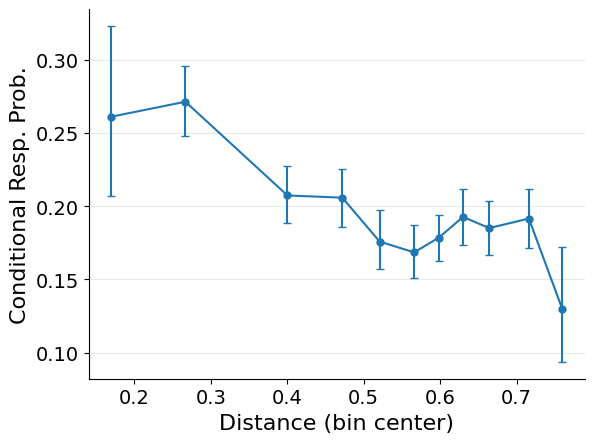

Mixed


<Figure size 640x480 with 0 Axes>

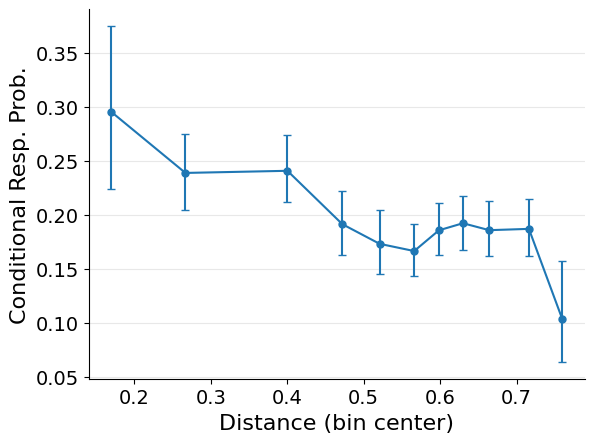

Pure emotional


<Figure size 640x480 with 0 Axes>

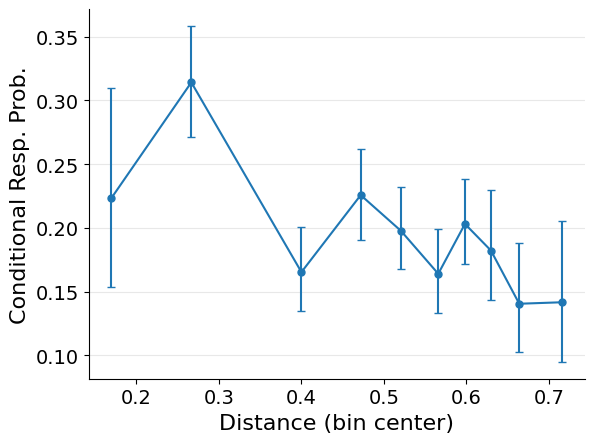

Pure neutral


<Figure size 640x480 with 0 Axes>

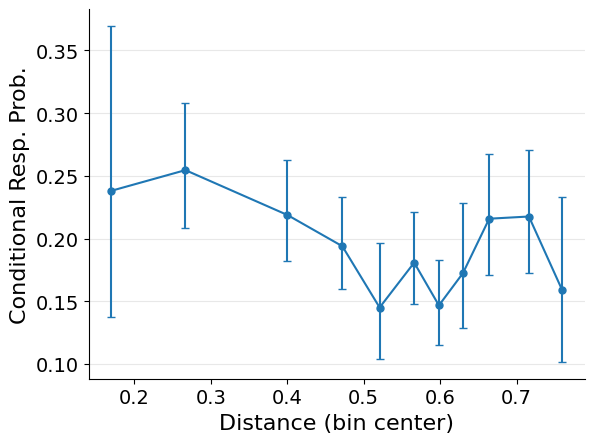

In [5]:
for i in range(len(trial_masks)):
    print(labels[i])
    plt.figure()
    plot_dist_crp(
        datasets=data,
        trial_masks=trial_masks[i],
        distance_matrix=distance_matrix,
        labels=[labels[i]],
        bin_edges=bin_edges,
        confidence_level=confidence_level,
    )
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    plt.show()
# save_figure(figure_dir, figure_str)


## Interpretation

The x-axis shows semantic-distance bins derived from pairwise human semantic-similarity ratings. Lower distances mean the just-recalled image and candidate image were rated as more semantically similar.

- **Downward slope**: higher transition probabilities for semantically similar images indicate semantic clustering.
- **Flat curve**: transitions are unrelated to semantic distance.
- **List-type separation**: differences among mixed, pure emotional, and pure neutral lists indicate that semantic organization differs by stimulus-list context.


## API Details

### Notebook parameters

- `data_path` - path to an HDF5 file containing a `RecallDataset`.
- `distance_matrix_path` - path to a numpy file containing a pairwise distance matrix indexed by item ID.
- `figure_dir` - directory for saving figures.
- `figure_str` - base filename for the saved figure. Leave empty to display without saving.
- `ylim` - y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_queries` - Python expressions evaluated against the dataset to select trials.
- `labels` - legend labels matching `trial_queries`.
- `bin_edges` - binning rule or explicit interior bin edges.
- `confidence_level` - confidence level for subject-wise error bars.

The standard Distance-CRP template demonstrates `features=`. This companion template demonstrates `distance_matrix=`.
